# FIFA World Cup 2026: Four Analytic Tasks
## HIT140 Foundations of Data Science · Assessment 2 · Objective 1

**Darwin Group 46**

| Member | Student ID | Task |
|---|---|---|
| Angel Shahi | s400420 | Task 1: Goal timing within a match |
| Nishant Shrestha | s400342 | Task 2: Team playing style |
| Sabraham Shrestha | s404389 | Task 3: Attacking output by position |
| Akash Singh | s401643 | Task 4: Schedule recovery |

---

Each task follows the **four-step process** from Week 4:

**Step 1 State** the practical question.
**Step 2 Plan** the hypotheses and the test.
**Step 3 Solve** by checking the conditions, then computing the statistics, the
confidence interval and the *t*-statistic.
**Step 4 Conclude** by answering the question in plain English.

Methods are limited to Weeks 1-5: Week 2 descriptive statistics and the 1.5 × IQR
outlier rule, the Week 3 confidence interval, and the Week 4 one-sample and
two-sample *t*-tests.

## Setup

Run this section first. It works the same way in Jupyter, VS Code and Google Colab.

If you are on Colab, the first cell asks you to upload the project zip and then moves
into the folder, because the notebook needs the `dataset` folder beside it. Anywhere
else it simply checks that the folder is there and carries on.

In [ ]:
import os, sys, subprocess, zipfile

# 1. install any missing libraries (does nothing if they're already there)
for pkg in ("pandas", "numpy", "matplotlib", "scipy"):
    try:
        __import__(pkg)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

# 2. find the dataset/ folder
ON_COLAB = "google.colab" in sys.modules
if ON_COLAB and not os.path.exists("dataset"):
    from google.colab import files  # type: ignore  # Colab-only; not installed elsewhere
    print("Choose the project zip from your computer ...")
    uploaded = files.upload()
    with zipfile.ZipFile(next(iter(uploaded))) as z:
        z.extractall()

# if the notebook was started from a different folder, step to the right one
for path in (".", "..", "WC2026_Objective1", "WC2026_Objective1final"):
    if os.path.isdir(os.path.join(path, "dataset")):
        os.chdir(path)
        break

print("working directory :", os.getcwd())
print("dataset folder    :", "found" if os.path.exists("dataset") else "NOT FOUND")

if not os.path.exists("dataset"):
    raise FileNotFoundError(
        "Open this notebook from the folder that also contains the 'dataset' folder.")

### Import the libraries we need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Week 3: z* for the confidence level we use throughout
Z_STAR = 1.960     # 95% confidence
ALPHA = 0.05       # Week 4: reject H0 when p <= 0.05

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)

print("Libraries loaded.")

Libraries loaded.


### Load the four data files

In [3]:
goals   = pd.read_csv("dataset/goals.csv")          # one row per goal scored
teams   = pd.read_csv("dataset/squad_profile.csv")   # one row per nation
players = pd.read_csv("dataset/players.csv")         # one row per player
rest    = pd.read_csv("dataset/rest.csv")            # one row per recovery interval
matches = pd.read_csv("dataset/matches.csv")         # one row per match
team_match = pd.read_csv("dataset/team_match.csv")   # one row per team per match

for name, df in [("goals", goals), ("teams", teams), ("players", players),
                 ("rest", rest), ("matches", matches), ("team_match", team_match)]:
    print(f"{name:11s} {df.shape[0]:>5} rows x {df.shape[1]:>3} columns")

goals         308 rows x  18 columns
teams          48 rows x  21 columns
players      1039 rows x  39 columns
rest          160 rows x   8 columns
matches       104 rows x  37 columns
team_match    208 rows x  16 columns


### Checking the data before we use it

The 2026 tournament had 48 teams, 104 matches and 308 goals. We check those numbers
before doing anything else, if a file is wrong, nothing below can be trusted.

Each check compares something we counted against something we know independently, and
`assert` stops the notebook if any of them fails.

In [4]:
checks = [
    ("nations",                    teams.shape[0],                        48),
    ("matches (from matches.csv)", matches.shape[0],                     104),
    ("goal events",                goals.shape[0],                       308),
    ("normal-time goals",          (goals.normal_time == True).sum(),    300),
    ("extra-time goals",           (goals.normal_time == False).sum(),     8),
    ("players",                    players.shape[0],                    1039),
    ("recovery intervals",         rest.shape[0],                        160),
    ("team-matches",               team_match.shape[0],                  208),
]

results = pd.DataFrame(checks, columns=["check", "we counted", "expected"])
results["passed"] = results["we counted"] == results["expected"]
display(results)

for _, row in results.iterrows():
    assert row["passed"], f"FAILED: {row['check']}"
print(f"All {len(results)} checks passed.")

,check,we counted,expected,passed
0,nations,48,48,True
1,matches (from matches.csv),104,104,True
2,goal events,308,308,True
3,normal-time goals,300,300,True
4,extra-time goals,8,8,True
5,players,1039,1039,True
6,recovery intervals,160,160,True
7,team-matches,208,208,True


All 8 checks passed.


Two more checks, this time comparing one file against another. These are
stronger, because each side is counted from a different table, they can only agree if
both tables describe the same tournament.

In [5]:
# The goals each team scored, counted from the goal events,
# should match the goals recorded against them in the team table.
goals_from_events = len(goals)
goals_from_players = players.goals.sum() + players.own_goals.sum()
print(f"goal events on the Goals sheet     : {goals_from_events}")
print(f"player goals + own goals           : {goals_from_players}")
assert goals_from_events == goals_from_players

# Every recovery interval must belong to one of the 48 nations.
print(f"\nnations appearing in rest.csv      : {rest.team.nunique()}")
assert rest.team.nunique() == 48

print("\nBoth cross-checks passed.")

goal events on the Goals sheet     : 308
player goals + own goals           : 308

nations appearing in rest.csv      : 48

Both cross-checks passed.


### Two helper functions

We use these in every task, so we write them once. Both come straight from the
lecture formulas.

In [6]:
def confidence_interval(x, z=Z_STAR):
    """Week 3:  CI = xbar +/- z* * s / sqrt(n)

    Needs n >= 30 for the Central Limit Theorem to apply.
    """
    x = x.dropna()
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)                 # sample standard deviation
    margin = z * s / np.sqrt(n)
    return mean, mean - margin, mean + margin, n


def describe(x, label=""):
    """Week 2 descriptive statistics, plus the 1.5 x IQR outlier count."""
    x = x.dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    outliers = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()
    return pd.Series({
        "n": len(x), "mean": x.mean(), "median": x.median(),
        "std dev": x.std(ddof=1), "variance": x.var(ddof=1),
        "min": x.min(), "Q1": q1, "Q3": q3, "IQR": iqr, "max": x.max(),
        "skewness": stats.skew(x, bias=False),
        "outliers (1.5xIQR)": outliers,
    }, name=label)

### The two *t*-tests, written from the Week 4 formulas

We compute the *t*-statistic by hand rather than calling a library function, so the
arithmetic in the code is the same arithmetic as in the lecture.

In [7]:
def one_sample_t(x, mu0, alternative="two-sided"):
    """Week 4:   t* = (xbar - mu0) / (s / sqrt(n)),   df = n - 1"""
    x = x.dropna()
    n = len(x)
    t = (x.mean() - mu0) / (x.std(ddof=1) / np.sqrt(n))
    df = n - 1
    if alternative == "greater":
        p = stats.t.sf(t, df)
    elif alternative == "less":
        p = stats.t.cdf(t, df)
    else:
        p = 2 * stats.t.sf(abs(t), df)
    return t, df, p


def two_sample_t(a, b, alternative="two-sided"):
    """Week 4, the independent two-sample test:

                   xbar1 - xbar2
        t* = ---------------------------      df = min(n1, n2) - 1
              sqrt( s1^2/n1 + s2^2/n2 )

    The variances are kept separate, and the degrees of freedom are the
    conservative choice the Week 4 example makes: the smaller sample, minus one.
    """
    a, b = a.dropna(), b.dropna()
    n1, n2 = len(a), len(b)
    t = (a.mean() - b.mean()) / np.sqrt(a.var(ddof=1)/n1 + b.var(ddof=1)/n2)
    df = min(n1, n2) - 1
    if alternative == "greater":
        p = stats.t.sf(t, df)
    elif alternative == "less":
        p = stats.t.cdf(t, df)
    else:
        p = 2 * stats.t.sf(abs(t), df)
    return t, df, p


def report(t, df, p):
    """Print the result in the APA format Week 4 asks for."""
    p_txt = "p < .001" if p < 0.001 else f"p = {p:.3f}".replace("0.", ".", 1)
    print(f"  t({df}) = {t:.2f}, {p_txt}")
    print(f"  {'REJECT H0' if p <= ALPHA else 'Fail to reject H0'} at alpha = {ALPHA}")

### The chart style used on the slides

Each of Tasks 2, 3 and 4 compares two groups, so all three use one chart. Writing it
once here keeps the three task sections short and guarantees the slides and the
notebook are drawing the same picture.

In [8]:
# The three two-group comparisons are all shown the same way on the slides: a box
# for the spread, one dot for every observation so nothing is hidden behind the
# summary, and a diamond on the group mean, which is the quantity the t-test is
# actually about.
def slide_box(groups, labels, ylabel, title, subtitle=""):
    colours = ["#2A78D6", "#EB6834"]
    rng = np.random.default_rng(42)          # fixed seed: the jitter is reproducible
    fig, ax = plt.subplots(figsize=(7.6, 4.4))

    box = ax.boxplot(groups, positions=range(len(groups)), widths=0.42,
                     patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", linewidth=1.6),
                     whiskerprops=dict(color="#8A8880"),
                     capprops=dict(color="#8A8880"))
    for i, patch in enumerate(box["boxes"]):
        patch.set(facecolor=colours[i], alpha=0.16,
                  edgecolor=colours[i], linewidth=1.6)

    for i, values in enumerate(groups):
        values = np.asarray(values, dtype=float)
        ax.scatter(i + rng.normal(0, 0.055, len(values)), values, s=13,
                   color=colours[i], alpha=0.45, edgecolors="white",
                   linewidths=0.5, zorder=3)
        ax.scatter([i], [values.mean()], marker="D", s=58, color=colours[i],
                   edgecolors="white", linewidths=1.6, zorder=5)
        ax.annotate(f"mean {values.mean():.2f}   n = {len(values)}",
                    (i, values.mean()), xytext=(16, 10),
                    textcoords="offset points", fontsize=9, va="bottom",
                    bbox=dict(boxstyle="round,pad=0.28", facecolor="white",
                              edgecolor="none", alpha=0.85))

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", pad=24 if subtitle else 12, fontweight="semibold")
    if subtitle:
        ax.text(0, 1.035, subtitle, transform=ax.transAxes, fontsize=9.5,
                color="#52514E", va="bottom")
    ax.grid(axis="y", color="#E4E3DF")
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    plt.show()

---
## Data preparation and feature engineering

**None of the four variables we analyse existed in any source file.** Each one had to
be built, and the choice of how to build it is most of the analysis. This section shows
the four, and why the obvious alternative does not work.

In [9]:
built = pd.DataFrame([
    ["1", "minute",
     "the published minute string, e.g. '90+4'",
     "goals per match cannot say WHEN a goal arrived"],
    ["2", "possession_pct",
     "FBref squad possession table",
     "total shots rewards a team for simply playing more matches"],
    ["3", "involvements_per90",
     "(goals + assists) / minutes x 90",
     "raw totals measure who was given minutes, not what they did"],
    ["4", "rest_days",
     "days to the NEXT match, per nation",
     "labelling by the PREVIOUS match misfiles the run-up to a knockout tie"],
], columns=["Task", "Variable we built", "Built from", "Why the obvious version fails"])
built

,Task,Variable we built,Built from,Why the obvious version fails
0,1,minute,"the published minute string, e.g. '90+4'",goals per match cannot say WHEN a goal arrived
1,2,possession_pct,FBref squad possession table,total shots rewards a team for simply playing ...
2,3,involvements_per90,(goals + assists) / minutes x 90,"raw totals measure who was given minutes, not ..."
3,4,rest_days,"days to the NEXT match, per nation",labelling by the PREVIOUS match misfiles the r...


### A closer look at one of them

`rest_days` is just a subtraction. The thinking is in the **labelling**: each interval
belongs to the match it leads *into*, not the one it follows.

In [10]:
rest[["team", "from_stage", "to_stage", "rest_days", "interval_label"]].head(6)

,team,from_stage,to_stage,rest_days,interval_label
0,Algeria,Group stage,Group stage,6,Before a group match
1,Algeria,Group stage,Group stage,5,Before a group match
2,Algeria,Group stage,Round of 32,5,Before a knockout match
3,Argentina,Group stage,Group stage,6,Before a group match
4,Argentina,Group stage,Group stage,5,Before a group match
5,Argentina,Group stage,Round of 32,6,Before a knockout match


In [11]:
# The same interval, labelled two different ways
print("Labelled by the match it LEADS INTO (what we use):")
print(rest.groupby("interval_label")["rest_days"].agg(["count", "mean"]).round(2))
print()
print("Labelled by the match it FOLLOWS (the obvious shortcut):")
print(rest.groupby("from_stage")["rest_days"].agg(["count", "mean"]).round(2))
print()
print("The shortcut hides the effect, because the last group-stage interval")
print("is actually the run-up to a Round of 32 tie.")

Labelled by the match it LEADS INTO (what we use):
                         count  mean
interval_label                      
Before a group match        96  5.54
Before a knockout match     64  4.91

Labelled by the match it FOLLOWS (the obvious shortcut):
               count  mean
from_stage                
Group stage      128  5.47
Quarter-final      4  4.25
Round of 16        8  4.75
Round of 32       16  4.69
Semi-final         4  4.00

The shortcut hides the effect, because the last group-stage interval
is actually the run-up to a Round of 32 tie.


---
# Task 1: Goal timing within a match
### Angel Shahi (s400420)

## Step 1: State

Football fans say goals come late in a match. Is that true, or do goals arrive evenly
across the ninety minutes?

If goals arrived at a **constant rate**, then the average minute of a randomly chosen
goal would be the middle of the match, the midpoint of minutes 1 to 90, which is
**45.5**. That gives us a value to test against.

**Question: does the mean minute of a goal differ from 45.5?**

## Step 2: Plan

There is only one group of goals and we are comparing their mean against a fixed
number, so this is a **one-sample** *t*-test.

$$H_0: \mu = 45.5 \qquad H_a: \mu \neq 45.5 \qquad \alpha = 0.05$$

Two-sided, because goals could plausibly come earlier (fresh legs, high tempo) or
later (tiredness, substitutes, teams chasing the game).

## Step 3: Solve

### Data preparation

We use only the goals scored inside normal time. The 8 extra-time goals are removed,
because extra time only happened in 9 matches and a goal in the 105th minute cannot be
compared against a 90-minute clock.

In [12]:
normal_time = goals[goals.normal_time == True].copy()

print("all goal events   :", len(goals))
print("extra-time goals  :", len(goals) - len(normal_time))
print("goals we analyse  :", len(normal_time))

minutes = normal_time["minute"]
minutes.head()

all goal events   : 308
extra-time goals  : 8
goals we analyse  : 300


0     9
1    67
2    67
3    80
4    59
Name: minute, dtype: int64

### Descriptive statistics

In [13]:
describe(minutes, "goal minute").round(3)

n                     300.000
mean                   52.653
median                 54.000
std dev                27.170
variance              738.234
min                     2.000
Q1                     31.000
Q3                     77.250
IQR                    46.250
max                    90.000
skewness               -0.214
outliers (1.5xIQR)      0.000
Name: goal minute, dtype: float64

### Check the conditions for inference

Week 4 asks us to check whether the sample looks normally distributed. We do that by
looking at the histogram, and we report the skewness and the outlier count so the
judgement is checkable.

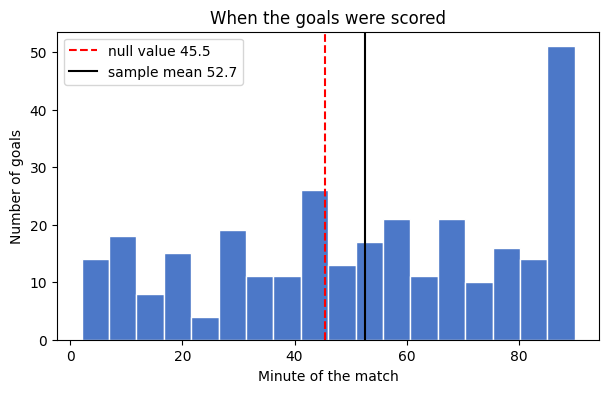

skewness      : -0.214  (close to 0 is symmetric)
sample size   : 300  (Week 3 wants at least 30)


In [14]:
plt.hist(minutes, bins=18, color="#4C78C8", edgecolor="white")
plt.axvline(45.5, color="red", linestyle="--", label="null value 45.5")
plt.axvline(minutes.mean(), color="black", label=f"sample mean {minutes.mean():.1f}")
plt.xlabel("Minute of the match")
plt.ylabel("Number of goals")
plt.title("When the goals were scored")
plt.legend()
plt.show()

print(f"skewness      : {stats.skew(minutes, bias=False):.3f}  (close to 0 is symmetric)")
print(f"sample size   : {len(minutes)}  (Week 3 wants at least 30)")

The distribution is roughly symmetric and n = 300 is far above 30, so the
Central Limit Theorem applies and the *t*-test is appropriate.

### Confidence interval

In [15]:
mean, low, high, n = confidence_interval(minutes)
print(f"Mean goal minute : {mean:.2f}")
print(f"95% CI           : [{low:.2f}, {high:.2f}]   (n = {n})")
print(f"\nThe null value 45.5 is {'inside' if low <= 45.5 <= high else 'OUTSIDE'} this interval.")

Mean goal minute : 52.65
95% CI           : [49.58, 55.73]   (n = 300)

The null value 45.5 is OUTSIDE this interval.


### The hypothesis test

In [16]:
t, df, p = one_sample_t(minutes, 45.5)
print("One-sample t-test,  H0: mu = 45.5")
report(t, df, p)

One-sample t-test,  H0: mu = 45.5
  t(299) = 4.56, p < .001
  REJECT H0 at alpha = 0.05


### Where in the match the goals fall

Splitting the ninety minutes into six fifteen-minute blocks makes the pattern easier to
see than the histogram alone.

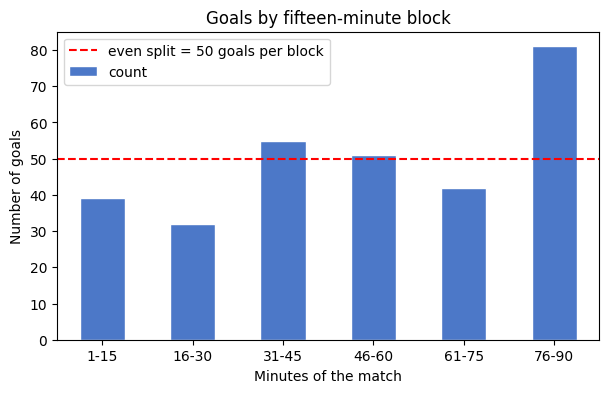

minute
1-15     39
16-30    32
31-45    55
46-60    51
61-75    42
76-90    81

first half : 126 goals
second half: 174 goals


In [17]:
blocks = pd.cut(minutes, bins=[0, 15, 30, 45, 60, 75, 90],
                labels=["1-15", "16-30", "31-45", "46-60", "61-75", "76-90"])
counts = blocks.value_counts().sort_index()

counts.plot(kind="bar", color="#4C78C8", edgecolor="white", rot=0)
plt.axhline(len(minutes) / 6, color="red", linestyle="--",
            label=f"even split = {len(minutes)/6:.0f} goals per block")
plt.ylabel("Number of goals")
plt.xlabel("Minutes of the match")
plt.title("Goals by fifteen-minute block")
plt.legend()
plt.show()

print(counts.to_string())
print(f"\nfirst half : {counts[:3].sum()} goals")
print(f"second half: {counts[3:].sum()} goals")

### The chart used on slide 4

The fifteen-minute blocks above answer the question, but they bury the single most
striking feature of the data inside the last block. Narrower bins bring it out.

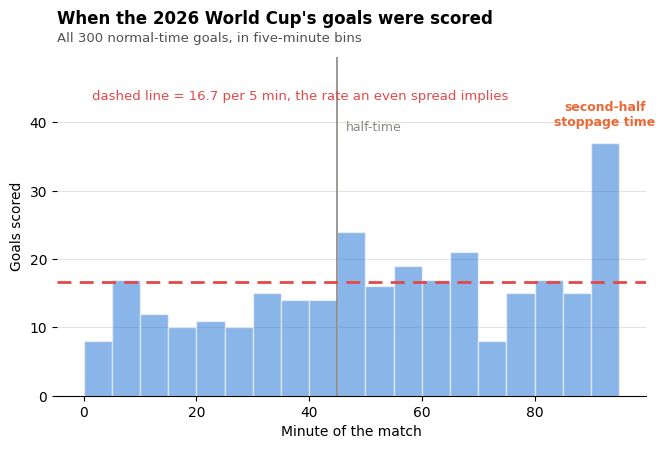

busiest five-minute bin : minutes 90-95  (37 goals, against 16.7 expected)


In [18]:
# The chart on slide 4: the same goals in five-minute bins, which is fine enough
# to show the stoppage-time spike that the fifteen-minute blocks hide inside 76-90.
counts, _ = np.histogram(minutes, bins=np.arange(0, 96, 5))
even_rate = len(minutes) / 18          # 18 bins of five minutes across 0-90

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.hist(minutes, bins=np.arange(0, 96, 5), color="#2A78D6", alpha=0.55,
        edgecolor="white", zorder=2)
ax.axhline(even_rate, color="#E34948", linewidth=2, linestyle=(0, (5, 3)), zorder=4)
ax.axvline(45, color="#8A8880", linewidth=1.2, zorder=3)
ax.set_ylim(0, counts.max() * 1.34)

ax.text(1.5, counts.max() * 1.16,
        f"dashed line = {even_rate:.1f} per 5 min, the rate an even spread implies",
        color="#E34948", fontsize=9.5, va="bottom")
ax.annotate("half-time", (45, counts.max() * 1.05), xytext=(6, 0),
            textcoords="offset points", fontsize=9, color="#8A8880")
ax.annotate("second-half\nstoppage time", (92.5, counts.max()), xytext=(0, 10),
            textcoords="offset points", fontsize=9, color="#EB6834",
            ha="center", va="bottom", fontweight="semibold")

ax.set_xlabel("Minute of the match")
ax.set_ylabel("Goals scored")
ax.set_title("When the 2026 World Cup's goals were scored", loc="left",
             pad=24, fontweight="semibold")
ax.text(0, 1.035, f"All {len(minutes)} normal-time goals, in five-minute bins",
        transform=ax.transAxes, fontsize=9.5, color="#52514E", va="bottom")
ax.grid(axis="y", color="#E4E3DF")
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
plt.show()

print(f"busiest five-minute bin : minutes {counts.argmax()*5}-{counts.argmax()*5+5}"
      f"  ({counts.max()} goals, against {even_rate:.1f} expected)")

### An alternative worth checking

A lot of goals are scored in added time, and our data records those at minute 90.
What happens if we leave them out?

In [19]:
no_stoppage = normal_time[normal_time.in_stoppage == False]["minute"]

print(f"Removed {len(minutes) - len(no_stoppage)} added-time goals")
print(f"Mean without them: {no_stoppage.mean():.2f}  (was {minutes.mean():.2f})\n")

t2, df2, p2 = one_sample_t(no_stoppage, 45.5)
report(t2, df2, p2)

Removed 46 added-time goals
Mean without them: 48.02  (was 52.65)

  t(253) = 1.56, p = .120
  Fail to reject H0 at alpha = 0.05


## Step 4: Conclude

The mean goal minute is **52.65**, with a 95% confidence interval of **[49.58, 55.73]**.
That interval does not contain 45.5, and the test rejects the null hypothesis:
**t(299) = 4.56, p < .001**.

So goals do arrive significantly later than a constant scoring rate would imply.

**But the honest version is narrower.** When the added-time goals are removed the mean
falls to 48.02 and the test no longer rejects. The late surplus is therefore
concentrated in added time rather than spread through the second half.

**Our claim: goals cluster late in a match, and overwhelmingly in added time.**

---
# Task 2: Team playing style
### Nishant Shrestha (s400342)

## Step 1: State

Commentators argue about whether keeping the ball actually wins matches. Plenty of
successful teams defend deep and counter-attack instead.

**Question: do the nations that reached the knockout stage hold more possession than
the nations eliminated in the group stage?**

We use **possession share** rather than total shots or total goals, because possession
is a percentage. A nation that played 7 matches and one that played 3 can be compared
directly, with no adjustment for how far they got.

## Step 2: Plan

Two independent groups of nations, so this is a **two-sample** *t*-test.

$$H_0: \mu_{knockout} = \mu_{group} \qquad H_a: \mu_{knockout} > \mu_{group} \qquad \alpha = 0.05$$

One-sided, because the coaching view we are testing predicts a direction: controlling
the ball is supposed to help you win.

## Step 3: Solve

### Data preparation

All 48 nations are used. We split them into the two groups.

In [20]:
knockout = teams[teams.reached_knockout == True]["possession_pct"]
group_exit = teams[teams.reached_knockout == False]["possession_pct"]

print("reached the knockout stage    :", len(knockout), "nations")
print("eliminated in the group stage :", len(group_exit), "nations")
print("total                         :", len(knockout) + len(group_exit))

reached the knockout stage    : 32 nations
eliminated in the group stage : 16 nations
total                         : 48


### Descriptive statistics

In [21]:
pd.DataFrame([describe(knockout, "Reached knockout"),
              describe(group_exit, "Eliminated in group")]).round(3)

,n,mean,median,std dev,variance,min,Q1,Q3,IQR,max,skewness,outliers (1.5xIQR)
Reached knockout,32.0,51.197,52.6,8.031,64.500,30.0,46.3,56.125,9.825,65.0,-0.728,1.0
Eliminated in group,16.0,43.494,41.0,10.230,104.659,30.7,38.3,46.025,7.725,66.3,1.112,2.0


### Check the conditions for inference

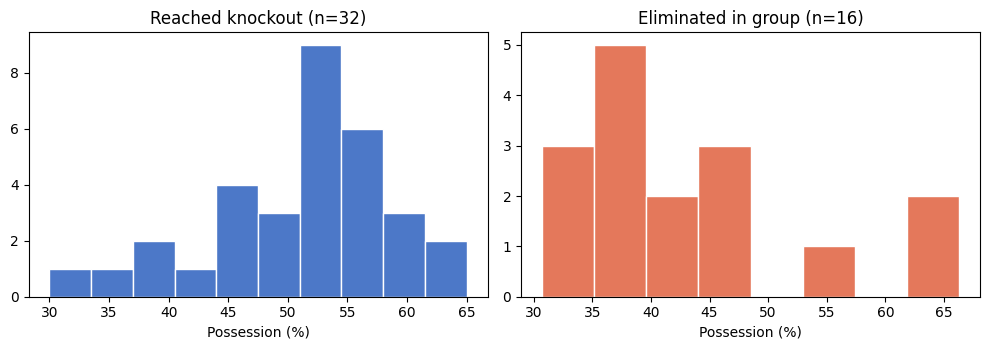

knockout    skewness -0.728   n = 32
group exit  skewness  1.112   n = 16


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(knockout, bins=10, color="#4C78C8", edgecolor="white")
ax[0].set_title(f"Reached knockout (n={len(knockout)})")
ax[1].hist(group_exit, bins=8, color="#E4785B", edgecolor="white")
ax[1].set_title(f"Eliminated in group (n={len(group_exit)})")
for a in ax:
    a.set_xlabel("Possession (%)")
plt.tight_layout(); plt.show()

for name, g in [("knockout", knockout), ("group exit", group_exit)]:
    print(f"{name:11s} skewness {stats.skew(g, bias=False):6.3f}   n = {len(g)}")

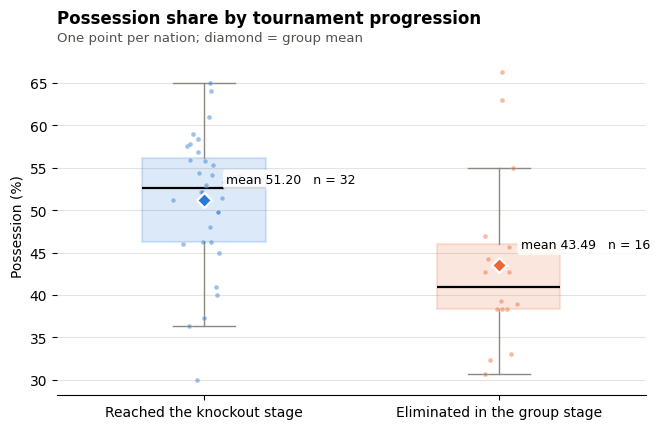

In [23]:
# This is the chart on slide 6.
slide_box([knockout, group_exit],
          ["Reached the knockout stage", "Eliminated in the group stage"],
          "Possession (%)",
          "Possession share by tournament progression",
          "One point per nation; diamond = group mean")

The group-exit sample is right-skewed and has only 16 nations, which is below
the 30 the Central Limit Theorem asks for. We report the test anyway, but we note this
as a limitation rather than pretending it is not there.

### Confidence interval

This interval is for the **average possession of a 2026 finalist**, using all 48 nations.

In [24]:
mean, low, high, n = confidence_interval(teams["possession_pct"])
print(f"Mean possession, all 48 nations : {mean:.2f}%")
print(f"95% CI                          : [{low:.2f}, {high:.2f}]   (n = {n})")

Mean possession, all 48 nations : 48.63%
95% CI                          : [45.95, 51.30]   (n = 48)


### The hypothesis test

In [25]:
print(f"knockout mean   : {knockout.mean():.2f}%")
print(f"group-exit mean : {group_exit.mean():.2f}%")
print(f"difference      : {knockout.mean() - group_exit.mean():.2f} percentage points\n")

t, df, p = two_sample_t(knockout, group_exit, alternative="greater")
print("Two-sample t-test,  H0: mu(knockout) = mu(group exit)")
report(t, df, p)

knockout mean   : 51.20%
group-exit mean : 43.49%
difference      : 7.70 percentage points

Two-sample t-test,  H0: mu(knockout) = mu(group exit)
  t(15) = 2.63, p = .009
  REJECT H0 at alpha = 0.05


### A rival explanation, tested

There is an obvious objection: maybe this is not about progression at all, but about
where a team comes from. European and South American nations tend to both keep the ball
**and** go further.

Confederation is fixed years before the tournament, so it cannot be a *consequence* of
progressing. If we split on that instead and get a similar gap, the two explanations are
tangled together.

In [26]:
established = teams[teams.confederation.isin(["UEFA", "CONMEBOL"])]["possession_pct"]
others      = teams[~teams.confederation.isin(["UEFA", "CONMEBOL"])]["possession_pct"]

print(f"UEFA / CONMEBOL      : {established.mean():.2f}%   (n = {len(established)})")
print(f"other confederations : {others.mean():.2f}%   (n = {len(others)})\n")

t2, df2, p2 = two_sample_t(established, others, alternative="greater")
report(t2, df2, p2)

UEFA / CONMEBOL      : 52.63%   (n = 22)
other confederations : 45.25%   (n = 26)

  t(21) = 2.93, p = .004
  REJECT H0 at alpha = 0.05


## Step 4: Conclude

Nations that reached the knockout stage averaged **51.20%** possession, against
**43.49%** for those eliminated in the group stage, a difference of **7.7 percentage
points**, which is statistically significant: **t(15) = 2.63, p = .009**.

The average 2026 finalist held **48.63%** of possession, 95% CI **[45.95, 51.30]**.

**Two limitations we report rather than hide.** The smaller group has only 16 nations
and is not symmetric. And splitting by confederation gives almost the same gap
(52.6% vs 45.2%, p = .004), which tells us the possession difference is real but that
**playing style and team strength are tangled together here**, and this design cannot
separate them.

---
# Task 3: Attacking output by position
### Sabraham Shrestha (s404389)

## Step 1: State

Forwards are supposed to be the players who make goals happen. But a forward who plays
20 minutes and a midfielder who plays 600 cannot be compared on totals.

**Question: do forwards produce more goal involvements per 90 minutes than midfielders?**

A *goal involvement* is a goal or an assist. We use it instead of assists alone, and we
use a **per 90 minutes** rate instead of a total. The next cells show why both choices
are necessary.

## Step 2: Plan

Two independent groups of players, so a **two-sample** *t*-test.

$$H_0: \mu_{forwards} = \mu_{midfielders} \qquad H_a: \mu_{forwards} > \mu_{midfielders} \qquad \alpha = 0.05$$

One-sided: forwards play in the positions goals are scored from, so the direction comes
from the role itself, not from looking at the data.

## Step 3: Solve

### Data preparation

We keep forwards and midfielders who played at least **180 minutes**, which is two full
matches. Below that a per-90 rate is meaningless: one goal in 15 minutes reads as 6.0
per 90.

In [27]:
used = players[(players.position_group.isin(["FW", "MF"])) &
               (players.minutes >= 180)].copy()

print("all players in the tournament :", len(players))
print("forwards and midfielders with 180+ minutes :", len(used))
print()
print(used.position_group.value_counts())

all players in the tournament : 1039
forwards and midfielders with 180+ minutes : 286

position_group
MF    213
FW     73
Name: count, dtype: int64


### Why assists alone do not work

Most players never record an assist, so the variable is almost all zeros and there is
nothing for a test to find.

In [28]:
for pos in ["FW", "MF"]:
    grp = used[used.position_group == pos]
    zeros = (grp.assists == 0).mean() * 100
    print(f"{pos}: {zeros:.0f}% of these players recorded no assists at all")

# assists measured the same way as our response variable - per 90 minutes
fw_assists = used[used.position_group == "FW"].eval("assists * 90 / minutes")
mf_assists = used[used.position_group == "MF"].eval("assists * 90 / minutes")

print(f"\nmedian assists per 90 - forwards    : {fw_assists.median():.3f}")
print(f"median assists per 90 - midfielders : {mf_assists.median():.3f}")

t_a, df_a, p_a = two_sample_t(fw_assists, mf_assists, alternative="greater")
print("\nIf we tested assists alone:")
report(t_a, df_a, p_a)

FW: 56% of these players recorded no assists at all
MF: 67% of these players recorded no assists at all

median assists per 90 - forwards    : 0.000
median assists per 90 - midfielders : 0.000

If we tested assists alone:
  t(72) = 1.46, p = .074
  Fail to reject H0 at alpha = 0.05


### Why raw totals do not work either

A starter simply plays more minutes than a substitute, so totals mostly measure who was
picked, not what they did.

In [29]:
print("mean minutes played:")
print(used.groupby("position_group")["minutes"].mean().round(0))
print("\nSo we divide by minutes and multiply by 90 to get a comparable rate.")

forwards    = used[used.position_group == "FW"]["involvements_per90"]
midfielders = used[used.position_group == "MF"]["involvements_per90"]

mean minutes played:
position_group
FW    320.0
MF    314.0
Name: minutes, dtype: float64

So we divide by minutes and multiply by 90 to get a comparable rate.


### Descriptive statistics

In [30]:
pd.DataFrame([describe(forwards, "Forwards"),
              describe(midfielders, "Midfielders")]).round(3)

,n,mean,median,std dev,variance,min,Q1,Q3,IQR,max,skewness,outliers (1.5xIQR)
Forwards,73.0,0.546,0.484,0.484,0.234,0.0,0.0,0.899,0.899,1.813,0.473,0.0
Midfielders,213.0,0.274,0.213,0.355,0.126,0.0,0.0,0.409,0.409,2.261,1.865,8.0


### Check the conditions for inference

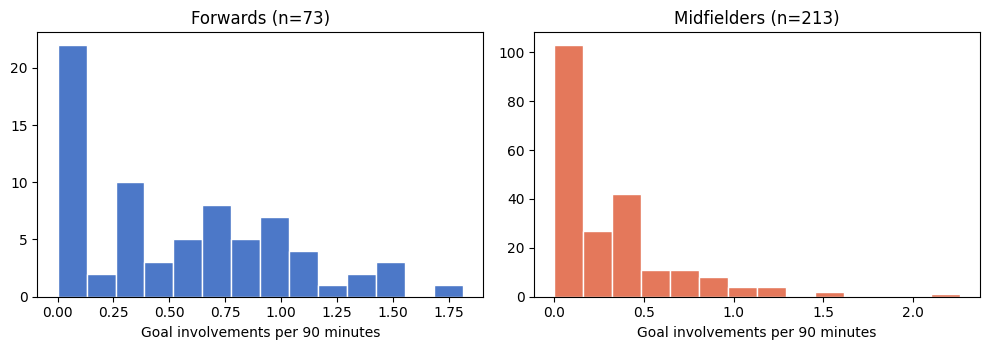

forwards     skewness  0.473   n = 73
midfielders  skewness  1.865   n = 213


In [31]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(forwards, bins=14, color="#4C78C8", edgecolor="white")
ax[0].set_title(f"Forwards (n={len(forwards)})")
ax[1].hist(midfielders, bins=14, color="#E4785B", edgecolor="white")
ax[1].set_title(f"Midfielders (n={len(midfielders)})")
for a in ax:
    a.set_xlabel("Goal involvements per 90 minutes")
plt.tight_layout(); plt.show()

for name, g in [("forwards", forwards), ("midfielders", midfielders)]:
    print(f"{name:12s} skewness {stats.skew(g, bias=False):6.3f}   n = {len(g)}")

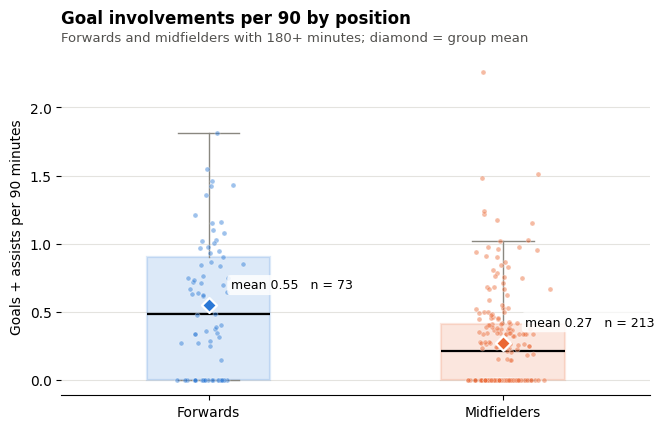

In [32]:
# This is the chart on slide 8.
slide_box([forwards, midfielders],
          ["Forwards", "Midfielders"],
          "Goals + assists per 90 minutes",
          "Goal involvements per 90 by position",
          "Forwards and midfielders with 180+ minutes; diamond = group mean")

Both groups are right-skewed, because a few players score a lot and most score little.
Both samples are well above 30, so the Central Limit Theorem carries the test.

### Confidence interval

In [33]:
mean, low, high, n = confidence_interval(used["involvements_per90"])
print(f"Mean involvements per 90, all {n} players : {mean:.3f}")
print(f"95% CI                                    : [{low:.3f}, {high:.3f}]")

Mean involvements per 90, all 286 players : 0.343
95% CI                                    : [0.296, 0.391]


### The hypothesis test

In [34]:
print(f"forwards    : {forwards.mean():.3f} involvements per 90")
print(f"midfielders : {midfielders.mean():.3f} involvements per 90")
print(f"ratio       : {forwards.mean() / midfielders.mean():.2f} times as many\n")

t, df, p = two_sample_t(forwards, midfielders, alternative="greater")
print("Two-sample t-test,  H0: mu(forwards) = mu(midfielders)")
report(t, df, p)

forwards    : 0.546 involvements per 90
midfielders : 0.274 involvements per 90
ratio       : 2.00 times as many

Two-sample t-test,  H0: mu(forwards) = mu(midfielders)
  t(72) = 4.42, p < .001
  REJECT H0 at alpha = 0.05


## Step 4: Conclude

Forwards produced **0.546** goal involvements per 90 minutes against **0.274** for
midfielders, about **twice as many**, and the difference is significant:
**t(72) = 4.42, p < .001**. Across all 286 players the mean was 0.343 per 90,
95% CI **[0.296, 0.391]**.

**The choice of variable is the whole analysis here.** On assists alone the comparison
fails to reject (**t(72) = 1.46, p = .074**), because most of these players never
recorded one, 56% of forwards and 67% of midfielders, so both medians are zero. On
raw totals it would mostly measure who was given minutes. Only goal involvements,
measured per 90, compares attacking output rather than squad status.

**A limitation:** players are clustered within nations. A strong attacking team lifts
all of its forwards, so the observations are not fully independent.

---
# Task 4: Schedule recovery
### Akash Singh (s401643)

## Step 1: State

The 2026 tournament expanded to 48 teams and added an extra knockout round. Any
squeeze in the calendar falls on the teams that go furthest.

**Question: does recovery time decrease in the knockout stage compared with the group
stage?**

A *recovery interval* is the number of days between one of a nation's matches and the
next. Each interval is labelled by the stage of the match it **leads into**, because
that is the match the rest affects.

## Step 2: Plan

Two independent groups of intervals, so a **two-sample** *t*-test.

$$H_0: \mu_{knockout} = \mu_{group} \qquad H_a: \mu_{knockout} < \mu_{group} \qquad \alpha = 0.05$$

One-sided, because the published calendar already told us the knockout rounds are
packed into a shorter window.

## Step 3: Solve

### Data preparation

There are 208 team-matches in the tournament (104 matches × 2 teams). A nation's first
match has no interval before it, so 48 drop out, leaving 160.

In [35]:
print("team-matches in the tournament :", 104 * 2)
print("minus each nation's first match :", -48)
print("recovery intervals              :", len(rest))

before_knockout = rest[rest.into_knockout == True]["rest_days"]
before_group    = rest[rest.into_knockout == False]["rest_days"]

print("\nbefore a knockout match :", len(before_knockout))
print("before a group match    :", len(before_group))

team-matches in the tournament : 208
minus each nation's first match : -48
recovery intervals              : 160

before a knockout match : 64
before a group match    : 96


### Descriptive statistics

In [36]:
pd.DataFrame([describe(before_knockout, "Before knockout match"),
              describe(before_group, "Before group match")]).round(3)

,n,mean,median,std dev,variance,min,Q1,Q3,IQR,max,skewness,outliers (1.5xIQR)
Before knockout match,64.0,4.906,5.0,1.050,1.102,3.0,4.0,5.0,1.0,8.0,1.042,5.0
Before group match,96.0,5.542,6.0,0.794,0.630,4.0,5.0,6.0,1.0,7.0,-0.527,0.0


### Check the conditions for inference

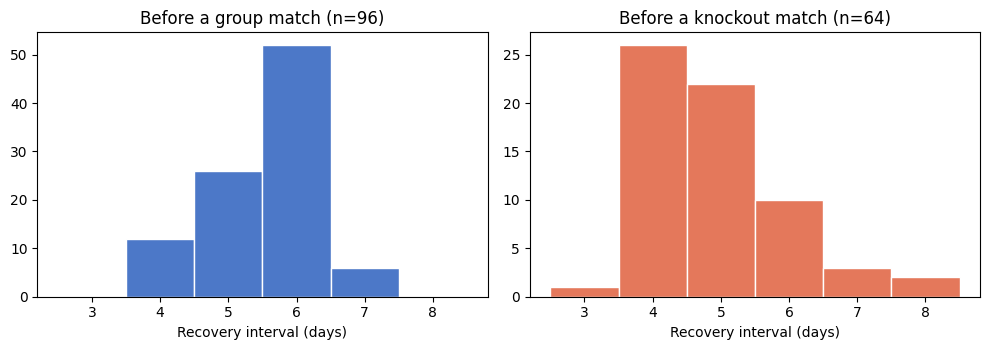

before group     skewness -0.527   n = 96
before knockout  skewness  1.042   n = 64


In [37]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
bins = np.arange(2.5, 9.5, 1)
ax[0].hist(before_group, bins=bins, color="#4C78C8", edgecolor="white")
ax[0].set_title(f"Before a group match (n={len(before_group)})")
ax[1].hist(before_knockout, bins=bins, color="#E4785B", edgecolor="white")
ax[1].set_title(f"Before a knockout match (n={len(before_knockout)})")
for a in ax:
    a.set_xlabel("Recovery interval (days)")
plt.tight_layout(); plt.show()

for name, g in [("before group", before_group), ("before knockout", before_knockout)]:
    print(f"{name:16s} skewness {stats.skew(g, bias=False):6.3f}   n = {len(g)}")

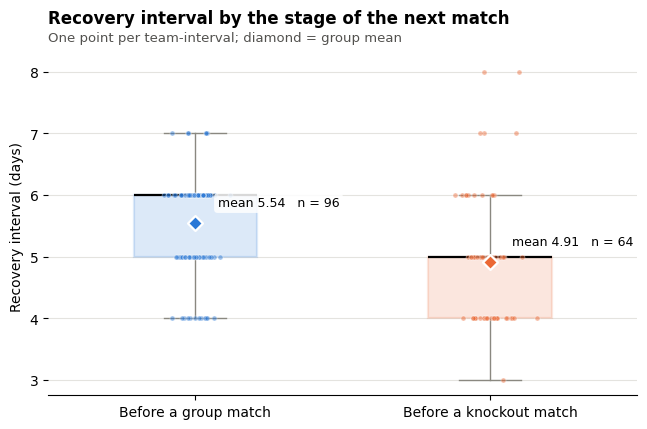

In [38]:
# This is the chart on slide 9.
slide_box([before_group, before_knockout],
          ["Before a group match", "Before a knockout match"],
          "Recovery interval (days)",
          "Recovery interval by the stage of the next match",
          "One point per team-interval; diamond = group mean")

### Recovery round by round

The compression is not spread evenly, it tightens as the bracket narrows.

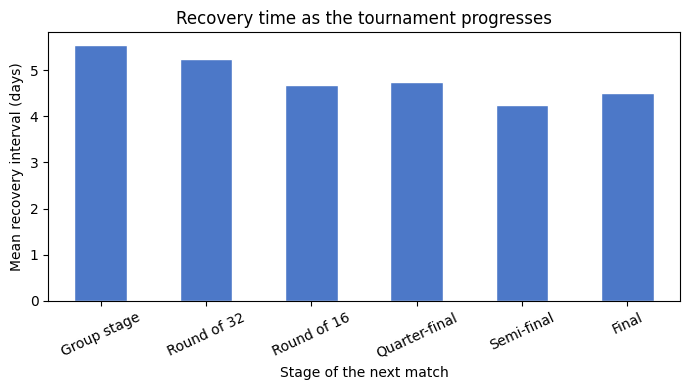

to_stage
Group stage      5.54
Round of 32      5.25
Round of 16      4.69
Quarter-final    4.75
Semi-final       4.25
Final            4.50


In [39]:
order = ["Group stage", "Round of 32", "Round of 16", "Quarter-final",
         "Semi-final", "Final"]
by_round = (rest[rest.to_stage.isin(order)]
            .groupby("to_stage")["rest_days"].mean()
            .reindex([o for o in order if o in set(rest.to_stage)]))

by_round.plot(kind="bar", color="#4C78C8", edgecolor="white", rot=25)
plt.ylabel("Mean recovery interval (days)")
plt.xlabel("Stage of the next match")
plt.title("Recovery time as the tournament progresses")
plt.tight_layout()
plt.show()

print(by_round.round(2).to_string())

The knockout group is right-skewed, because a few teams had unusually long
waits. Both samples are above 30, so the Central Limit Theorem applies.

### Confidence interval

In [40]:
mean, low, high, n = confidence_interval(rest["rest_days"])
print(f"Mean recovery interval, all {n} intervals : {mean:.2f} days")
print(f"95% CI                                    : [{low:.2f}, {high:.2f}]")

Mean recovery interval, all 160 intervals : 5.29 days
95% CI                                    : [5.14, 5.44]


### The hypothesis test

In [41]:
print(f"before a group match    : {before_group.mean():.2f} days")
print(f"before a knockout match : {before_knockout.mean():.2f} days")
print(f"difference              : {before_knockout.mean() - before_group.mean():.2f} days\n")

t, df, p = two_sample_t(before_knockout, before_group, alternative="less")
print("Two-sample t-test,  H0: mu(knockout) = mu(group)")
report(t, df, p)

before a group match    : 5.54 days
before a knockout match : 4.91 days
difference              : -0.64 days

Two-sample t-test,  H0: mu(knockout) = mu(group)
  t(63) = -4.12, p < .001
  REJECT H0 at alpha = 0.05


### A second question: is the squeeze fair?

The knockout stage shortens recovery for everyone. But does it hand an *advantage* to
some teams over others?

In every knockout tie the two teams play on the same day at the same venue, so the only
difference between them is how long each had rested. That makes the two values **paired**.

Week 4 handles a paired design the same way as the cola example: take the
**differences**, then run a **one-sample** *t*-test on those differences against zero.

In [42]:
# Load the pairs: for each knockout tie, the winner's rest minus the loser's rest
pairs = pd.read_csv("dataset/rest_pairs.csv")
print(f"knockout ties: {len(pairs)}\n")
pairs.head()

knockout ties: 32



,match_id,stage,winner,loser,winner_rest,loser_rest
0,73,Round of 32,Canada,South Africa,4,4
1,74,Round of 32,Paraguay,Germany,4,4
2,75,Round of 32,Morocco,Netherlands,5,4
3,76,Round of 32,Brazil,Japan,5,4
4,77,Round of 32,France,Sweden,4,5


In [43]:
differences = pairs["winner_rest"] - pairs["loser_rest"]

print(f"mean difference (winner - loser) : {differences.mean():.3f} days\n")

t_p, df_p, p_p = one_sample_t(differences, 0)
print("One-sample t-test on the paired differences,  H0: mu(difference) = 0")
report(t_p, df_p, p_p)

mean difference (winner - loser) : -0.062 days

One-sample t-test on the paired differences,  H0: mu(difference) = 0
  t(31) = -0.39, p = .701
  Fail to reject H0 at alpha = 0.05


## Step 4: Conclude

Teams had **4.91** days of recovery before a knockout match against **5.54** before a
group match. Recovery time was **significantly shorter in the knockout stage**, by
about two-thirds of a day: **t(63) = -4.12, p < .001**. Across all 160 intervals the
mean was 5.29 days, 95% CI **[5.14, 5.44]**.

**The second question gives a different answer.** Comparing the two teams within each
knockout tie, the winner's rest advantage averaged only −0.06 days and the paired test
does not reject (**t(31) = −0.39, p = .701**).

**So the bracket takes recovery from everyone who survives, but it does not favour the
teams that go on to win.** Two findings from one variable.

**A limitation:** intervals are nested within nations. A team that played seven matches
contributes six intervals, so they are not fully independent.

---
# Summary of all four tasks

In [44]:
summary = pd.DataFrame([
    ["1", "Angel Shahi",       "Goal timing",       "goal event",        300, "One-sample t",  4.56, 299, "< .001"],
    ["2", "Nishant Shrestha",  "Team playing style","nation",             48, "Two-sample t",  2.63,  15, "= .009"],
    ["3", "Sabraham Shrestha", "Attacking output",  "player",            286, "Two-sample t",  4.42,  72, "< .001"],
    ["4", "Akash Singh",       "Schedule recovery", "recovery interval", 160, "Two-sample t", -4.12,  63, "< .001"],
], columns=["Task", "Owner", "Focal point", "Unit of analysis", "n", "Test", "t", "df", "p"])
summary

,Task,Owner,Focal point,Unit of analysis,n,Test,t,df,p
0,1,Angel Shahi,Goal timing,goal event,300,One-sample t,4.56,299,< .001
1,2,Nishant Shrestha,Team playing style,nation,48,Two-sample t,2.63,15,= .009
2,3,Sabraham Shrestha,Attacking output,player,286,Two-sample t,4.42,72,< .001
3,4,Akash Singh,Schedule recovery,recovery interval,160,Two-sample t,-4.12,63,< .001


All four tests reject the null hypothesis at α = 0.05.

Because we chose the four questions after looking at the data, running four tests
raises the chance that at least one rejection happens by luck. We state that plainly
rather than ignoring it, and every one of the four is decided well below 0.05.

## What each task may and may not claim

| # | What we found | What we cannot say |
|---|---|---|
| 1 | Goals cluster late, mostly in added time | Remove added-time goals and the effect is no longer significant |
| 2 | Nations that advanced held more possession | Style and strength are tangled; this design cannot separate them |
| 3 | Forwards out-produce midfielders per 90 | Players are clustered within nations |
| 4 | The knockout stage shortens recovery | It does so even-handedly, winners get no advantage |

## Methods used

Everything here comes from Weeks 1 to 5:

- **Week 2**, mean, median, standard deviation, variance, IQR, the 1.5 × IQR outlier rule, skewness, histograms
- **Week 3**, the Central Limit Theorem and the confidence interval $\bar{x} \pm z^{*} \frac{s}{\sqrt{n}}$ with $z^{*} = 1.960$
- **Week 4**, the four-step process, the one-sample *t*-test, and the two-sample independent *t*-test with df = min(n₁, n₂) − 1
- **Week 5**, pandas for loading, filtering and grouping the data